In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, DecisionTreeClassifier, DecisionTreeRegressor
print('Sucesso')

In [4]:
dados = r"C:\Users\joth1\Downloads\credit_risk_dataset.csv"
df = pd.read_csv(dados)
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [6]:
df_2 = df[['person_age', 'person_income', 'loan_intent', 'loan_status']]
df_2

,person_age,person_income,loan_intent,loan_status
0,22,59000,PERSONAL,1
1,21,9600,EDUCATION,0
2,25,9600,MEDICAL,1
3,23,65500,MEDICAL,1
4,24,54400,MEDICAL,1
...,...,...,...,...
32576,57,53000,PERSONAL,0
32577,54,120000,PERSONAL,0
32578,65,76000,HOMEIMPROVEMENT,1
32579,56,150000,PERSONAL,0


In [19]:
df_final = pd.get_dummies(df_2, columns=["loan_intent"])
df_final

,person_age,person_income,loan_status,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,1,False,False,False,False,True,False
1,21,9600,0,False,True,False,False,False,False
2,25,9600,1,False,False,False,True,False,False
3,23,65500,1,False,False,False,True,False,False
4,24,54400,1,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...
32576,57,53000,0,False,False,False,False,True,False
32577,54,120000,0,False,False,False,False,True,False
32578,65,76000,1,False,False,True,False,False,False
32579,56,150000,0,False,False,False,False,True,False


In [21]:
x = df_final[['person_age', 'person_income', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']].values

y = df_final['loan_status'].values

In [24]:
from sklearn.model_selection import train_test_split

# Separar hold-out (teste final) primeiro
X_temp, X_holdout, y_temp, y_holdout = train_test_split(x, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42)

In [36]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

arvore = DecisionTreeClassifier(criterion='entropy', max_depth=3,random_state=42)
arvore.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [37]:
# arvore.feature_importances_.argsort()
arvore.feature_importances_

array([0.        , 0.96964524, 0.02071401, 0.        , 0.00964075,
       0.        , 0.        , 0.        ])

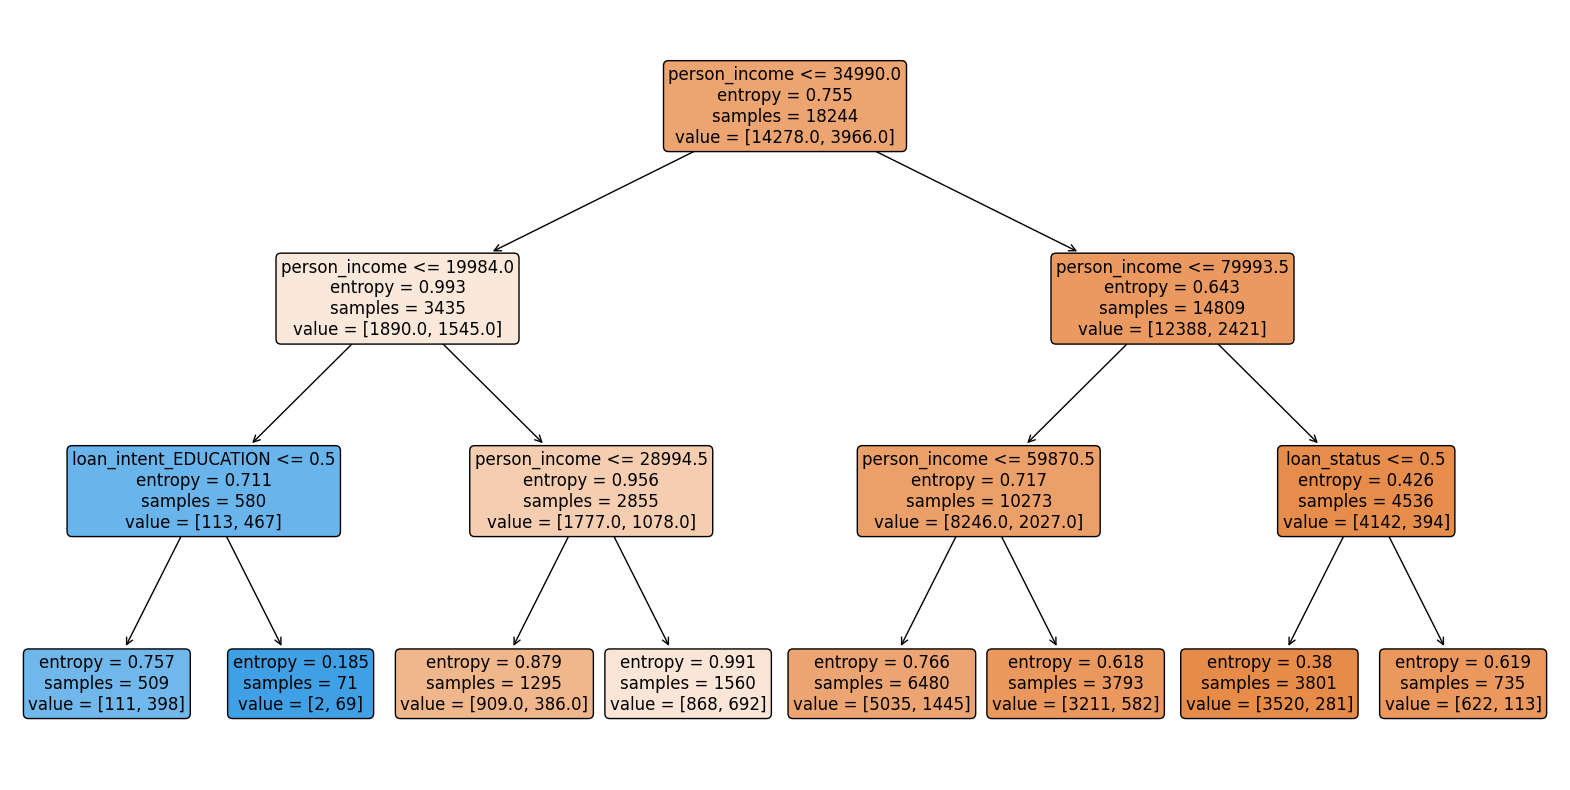

In [76]:
# plot_tree(arvore, filled=True)

from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))  # aumentar o tamanho
tree.plot_tree(
    arvore,
    feature_names=df_final.columns,
    # class_names=['Classe0', 'Classe1'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()



In [53]:
y_pred = arvore.predict(X_holdout)
# arvore.score(X_test, y_test)

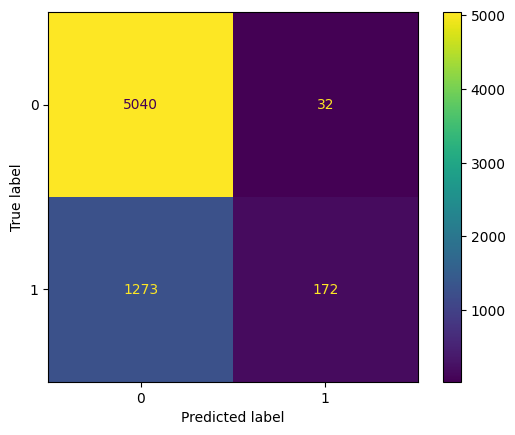

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Criar a matriz
cm = confusion_matrix(y_holdout, y_pred)

# Mostrar de forma visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


##### Precision → das previsões que o modelo disse “positivo”, quantas estavam certas.
##### Recall → dos casos realmente positivos, quantos o modelo conseguiu identificar.
##### F1-score → média balanceada entre precision e recall, útil quando há classes desbalanceadas.
##### Accuracy → percentual de acertos no geral.

In [58]:
from sklearn.metrics import classification_report, accuracy_score
# Métricas detalhadas por classe: precision, recall, f1-score
print(classification_report(y_holdout, y_pred))

# Accuracy geral do modelo
print("Accuracy:", accuracy_score(y_holdout, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.99      0.89      5072
           1       0.84      0.12      0.21      1445

    accuracy                           0.80      6517
   macro avg       0.82      0.56      0.55      6517
weighted avg       0.81      0.80      0.74      6517

Accuracy: 0.79975448826147
